# Imports and installing packages

In [1]:
!pip install -q "tensorflow==2.11.*"
!pip install -q "tensorflow_io==0.28.*"

ERROR: Could not find a version that satisfies the requirement tensorflow==2.11.* (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.11.*
ERROR: Ignored the following versions that require a different python version: 0.28.0 Requires-Python >=3.7, <3.11
ERROR: Could not find a version that satisfies the requirement tensorflow_io==0.28.* (from versions: 0.29.0, 0.30.0, 0.31.0, 0.32.0, 0.33.0, 0.34.0, 0.35.0, 0.36.0, 0.37.0, 0.37.1)
ERROR: No matching distribution found for tensorflow_io==0.28.*


In [1]:
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio

import soundfile as sf
import scipy.signal

2025-09-23 17:58:43.448362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758650323.623872      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758650323.675111      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_uti

In [2]:
def plots(history, path_to_save_fig=None, xlim=None, ylim=None):
       
    if hasattr(history, 'history'):
        history = history.history
    
    plt.figure(figsize=(7, 4))
    plt.subplot(1, 1, 1)
    
    # Aumenta a espessura da linha e o tamanho do texto
    plt.plot(history['accuracy'], '-', label='Accuracy on the training set', linewidth=4)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)  # Label do eixo Y
    
    if 'val_accuracy' in history.keys():
        plt.plot(history['val_accuracy'], '--', label='Accuracy on the validation set', linewidth=4)
        plt.title(
            f"Accuracy on the validation set: {np.max(history['val_accuracy']):.1%} (Best) | "
            f"{history['val_accuracy'][-1]:.1%} (Last)",
            fontsize=12
        )
    
    plt.legend(fontsize=12)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(True)
    plt.tick_params(axis='both', labelsize=10)  # Aumenta números nos eixos
    if path_to_save_fig is not None:
        plt.savefig(path_to_save_fig, format='svg', bbox_inches='tight')
    
    plt.show()

# Loading the model

In [3]:
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

I0000 00:00:1758650346.086966      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# testing one sample

In [4]:
testing_wav_file_name = tf.keras.utils.get_file('miaow_16k.wav',
                                                'https://storage.googleapis.com/audioset/miaow_16k.wav',
                                                cache_dir='./',
                                                cache_subdir='test_data')

print(testing_wav_file_name)

215546/215546 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
./test_data/miaow_16k.wav


In [5]:
def load_wav_16k_mono(filename):
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)

    wav_np = wav.numpy()
    sample_rate = int(sample_rate.numpy())
    
    # Apenas resample se necessário
    if sample_rate != 16000:
        number_of_samples = round(len(wav_np) * float(16000) / sample_rate)
        wav_np = scipy.signal.resample(wav_np, number_of_samples)
    
    return wav_np.astype(np.float32)

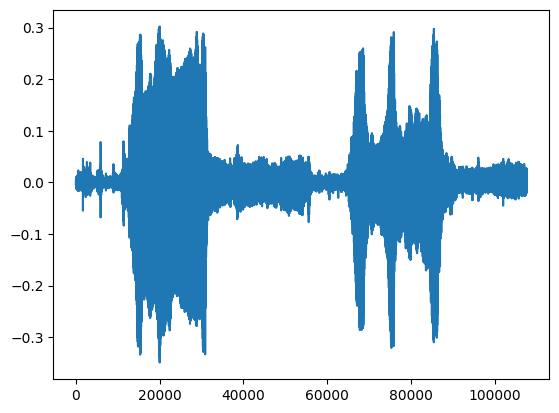

In [6]:
testing_wav_data = load_wav_16k_mono(testing_wav_file_name)

_ = plt.plot(testing_wav_data)

# Play the audio file.
display.Audio(testing_wav_data, rate=16000)

# Load class mapping 

In [7]:
class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
class_names =list(pd.read_csv(class_map_path)['display_name'])

for name in class_names[:20]:
  print(name)
print('...')

Speech
Child speech, kid speaking
Conversation
Narration, monologue
Babbling
Speech synthesizer
Shout
Bellow
Whoop
Yell
Children shouting
Screaming
Whispering
Laughter
Baby laughter
Giggle
Snicker
Belly laugh
Chuckle, chortle
Crying, sobbing
...


# Run inference

In [8]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]

print(f'The main sound is: {inferred_class}')
print(f'The embeddings shape: {embeddings.shape}')

I0000 00:00:1758650355.479815      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


The main sound is: Animal
The embeddings shape: (13, 1024)


# esc-50 dataset

In [9]:
_ = tf.keras.utils.get_file('esc-50.zip',
                        'https://github.com/karoldvl/ESC-50/archive/master.zip',
                        cache_dir='./',
                        cache_subdir='datasets',
                        extract=True)

645701632/Unknown 45s 0us/step

In [10]:
esc50_csv = '/kaggle/working/datasets/esc-50_extracted/ESC-50-master/meta/esc50.csv'
base_data_path = '/kaggle/working/datasets/esc-50_extracted/ESC-50-master/audio/'

pd_data = pd.read_csv(esc50_csv)
pd_data.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [11]:
'''my_classes = ['dog', 'chirping_birds', 'vacuum_cleaner', 'thunderstorm', 'door_wood_knock',
 'can_opening','crow', 'clapping', 'fireworks', 'chainsaw', 'airplane',
 'mouse_click', 'pouring_water', 'train', 'sheep', 'water_drops',
 'church_bells', 'clock_alarm' ,'keyboard_typing', 'wind', 'footsteps' ,'frog',
 'cow', 'brushing_teeth', 'car_horn', 'crackling_fire', 'helicopter',
 'drinking_sipping', 'rain', 'insects', 'laughing', 'hen','engine', 'breathing',
 'crying_baby', 'hand_saw', 'coughing', 'glass_breaking', 'snoring',
 'toilet_flush', 'pig', 'washing_machine', 'clock_tick', 'sneezing' ,'rooster',
 'sea_waves', 'siren', 'cat', 'door_wood_creaks','crickets']'''

my_classes = ['chainsaw', 'footsteps', 'crackling_fire', 'rain',
 'engine', 'hand_saw']
map_class_to_id = {}
for i in range(len(my_classes)):
  map_class_to_id[my_classes[i]] = i

filtered_pd = pd_data[pd_data.category.isin(my_classes)]

class_id = filtered_pd['category'].apply(lambda name: map_class_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda row: os.path.join(base_data_path, row))
filtered_pd = filtered_pd.assign(filename=full_path)

filtered_pd.head(100)

,filename,fold,target,category,esc10,src_file,take
24,/kaggle/working/datasets/esc-50_extracted/ESC-...,1,0,chainsaw,True,116765,A
39,/kaggle/working/datasets/esc-50_extracted/ESC-...,1,1,footsteps,False,155858,A
40,/kaggle/working/datasets/esc-50_extracted/ESC-...,1,1,footsteps,False,155858,B
41,/kaggle/working/datasets/esc-50_extracted/ESC-...,1,1,footsteps,False,155858,C
42,/kaggle/working/datasets/esc-50_extracted/ESC-...,1,1,footsteps,False,155858,D
...,...,...,...,...,...,...,...
770,/kaggle/working/datasets/esc-50_extracted/ESC-...,2,3,rain,True,87781,A
805,/kaggle/working/datasets/esc-50_extracted/ESC-...,3,5,hand_saw,False,102583,A
806,/kaggle/working/datasets/esc-50_extracted/ESC-...,3,5,hand_saw,False,102583,B
807,/kaggle/working/datasets/esc-50_extracted/ESC-...,3,5,hand_saw,False,102583,C


# Load the audio file and retrieve the embendings

In [12]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [13]:
def _load_and_resample_py(path):
    # path virá como tf.Tensor contendo bytes
    fn = path.numpy().decode()
    import soundfile as sf
    wav, sr = sf.read(fn, dtype='float32')  # ou use tf.audio.decode_wav + vogais numpy
    if sr != 16000:
        n_new = round(len(wav) * 16000 / sr)
        wav = scipy.signal.resample(wav, n_new)
    return wav.astype(np.float32)

def load_wav_for_map(filename, label, fold):
    # tf.py_function executa o _load_and_resample_py em modo eager
    wav = tf.py_function(func=_load_and_resample_py,
                         inp=[filename],
                         Tout=tf.float32)
    # Como o Tensor retornado por py_function fica sem shape, você precisa definir:
    wav.set_shape([None])
    return wav, label, fold


In [14]:
main_ds = main_ds.map(load_wav_for_map, num_parallel_calls=tf.data.AUTOTUNE)
print(main_ds.element_spec)

(TensorSpec(shape=(None,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


In [15]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet_model(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

# Split the data

In [16]:
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 4)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 4)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 5)

# remove the folds column now that it's not needed anymore
remove_fold_column = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold_column)
val_ds = val_ds.map(remove_fold_column)
test_ds = test_ds.map(remove_fold_column)

train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

# Create the model

In [17]:
total_ds = train_ds.concatenate(val_ds)


In [18]:
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(my_classes))
], name='my_model')

my_model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,878 (2.01 MB)

 Trainable params: 527,878 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
my_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [20]:
history = my_model.fit(total_ds,
                       epochs=20,
                       validation_data=test_ds,
                       callbacks=callback)

Epoch 1/20


I0000 00:00:1758650413.338713      96 service.cc:148] XLA service 0x7af3a80047f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758650413.340388      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
E0000 00:00:1758650413.798003      96 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


      6/Unknown 5s 34ms/step - accuracy: 0.3280 - loss: 1.8811

I0000 00:00:1758650414.162916      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     46/Unknown 9s 79ms/step - accuracy: 0.7092 - loss: 1.0998

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.7428 - loss: 1.0140 - val_accuracy: 0.8542 - val_loss: 0.4165
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9187 - loss: 0.2701 - val_accuracy: 0.8854 - val_loss: 0.4258
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9469 - loss: 0.2569 - val_accuracy: 0.8667 - val_loss: 0.3239
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9552 - loss: 0.1521 - val_accuracy: 0.8729 - val_loss: 0.3388
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9649 - loss: 0.1248 - val_accuracy: 0.8833 - val_loss: 0.3416
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9684 - loss: 0.1329 - val_accuracy: 0.8792 - val_loss: 0.3056
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9699 - loss: 0.0938 - val_accuracy: 0.8896 - val_loss: 0.2994
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9755 - loss: 0.0754 - val_accuracy: 0.8875 - val_loss: 0.3148
E

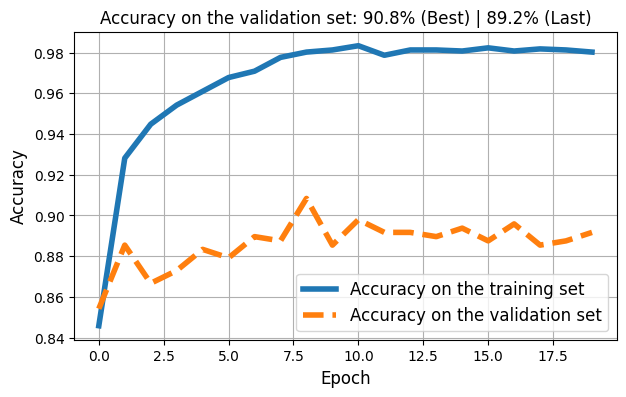

In [21]:
plots(history= history, path_to_save_fig="/kaggle/working/train_curve.svg", xlim=None, ylim=None)


# eval on the test set

In [22]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8804 - loss: 0.3952
Loss:  0.34502846002578735
Accuracy:  0.8916666507720947


In [23]:
# ————————————————
# 1) Extrai y_actual do test_ds sem invocar .numpy() dentro do loop do grafo
flat_labels = test_ds.unbatch().map(lambda emb, lab: lab)
# agora obtemos um iterador que devolve scalars NumPy
y_actual = [int(lab) for lab in flat_labels.as_numpy_iterator()]

In [24]:
import sklearn
from sklearn import metrics
#from tensorflow.keras.optimizers.Adam import Adam

#The "folds" earlier ensured that every thing is equal, so weighted average is same. Mention in report.

def run_tests():
  accuracies = []
  precisions = []
  recalls = []
  f1_scores = []
  
  yhat_probs = my_model.predict(test_ds, verbose=0)
  yhat_preds = [np.argmax(result) for result in yhat_probs]  

  accuracies.append(round(metrics.accuracy_score(y_actual, yhat_preds),3))
  recalls.append(round(metrics.recall_score(y_actual, yhat_preds, average='weighted'),3))
  precisions.append(round(metrics.precision_score(y_actual, yhat_preds, average='weighted'),3))
  f1_scores.append(round(metrics.f1_score(y_actual, yhat_preds, average='weighted'),3))

  print(f"Acuracies:{accuracies}")
  print(f"Recalls:{recalls}")
  print(f"Precisions:{precisions}")
  print(f"F1_scores:{f1_scores}")

In [25]:
run_tests()

Acuracies:[0.892]
Recalls:[0.892]
Precisions:[0.893]
F1_scores:[0.889]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns

def plot_confusion_matrix_from_ds(
    model,
    test_ds,
    classes,
    normalize=False,
    title='Confusion Matrix',
    path_to_save_fig=None
):
    """
    Gera e plota a matriz de confusão usando um tf.data.Dataset de teste.

    Parâmetros:
    - model: tf.keras.Model já carregado.
    - test_ds: tf.data.Dataset retornando tuplas (x_batch, y_batch).
    - classes: lista de nomes das classes (ordenados conforme encoding).
    - normalize: se True, normaliza cada linha.
    - title: título do gráfico.
    - path_to_save_fig: caminho para salvar a figura (opcional).
    """

    # coleta predições e rótulos reais
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_ds:
        yhat_probs = model.predict(x_batch, verbose=0)
        batch_preds = np.argmax(yhat_probs, axis=1)
        y_pred.extend(batch_preds.tolist())
        y_true.extend(y_batch.numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # calcula métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Acurácia: {acc:.3f}")
    print(f"Precision (weighted): {prec:.3f}")
    print(f"Recall (weighted): {rec:.3f}")
    print(f"F1-score (weighted): {f1:.3f}")

    # calcula matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'

    # plot com seaborn
    fig, ax = plt.subplots(figsize=(11, 9))
    heatmap = sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=plt.cm.Blues,
        xticklabels=classes,
        yticklabels=classes,
        cbar=True,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 24}
    )

    # ajusta a colorbar
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=20)

    ax.set_ylabel('True Label', fontsize=20)
    ax.set_xlabel('Predicted Label', fontsize=20)
    ax.set_xticklabels(classes, fontsize=22, rotation=45, ha='right')
    ax.set_yticklabels(classes, fontsize=22, rotation=0)
    if title:
        ax.set_title(title, fontsize=22)

    plt.tight_layout()
    if path_to_save_fig is not None: 
        plt.savefig(path_to_save_fig, format='svg', bbox_inches='tight')
    plt.show()


Acurácia: 0.892
Precision (weighted): 0.893
Recall (weighted): 0.892
F1-score (weighted): 0.889


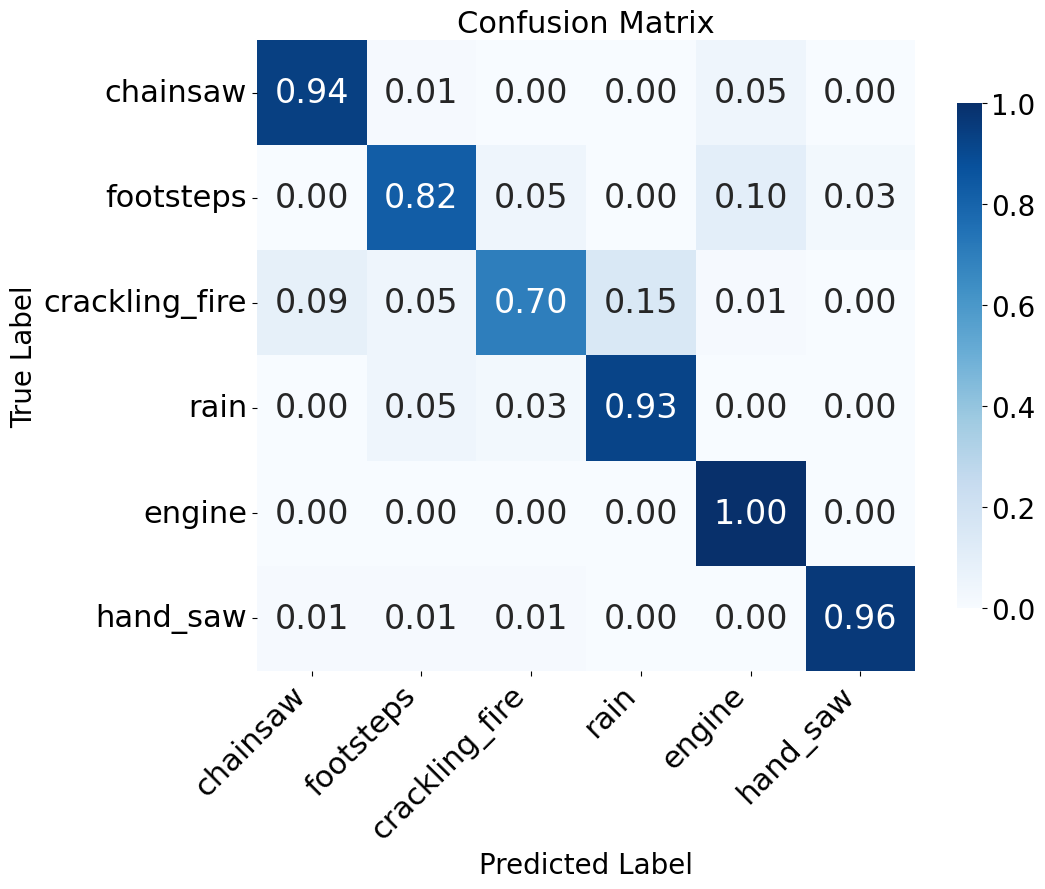

In [27]:
plot_confusion_matrix_from_ds(
    my_model,
    test_ds,
    map_class_to_id,
    normalize=True,
    title='Confusion Matrix',
    path_to_save_fig="/kaggle/working/confusion_matrix.svg"
)

# I on a single file

In [28]:
import numpy as np
import tensorflow as tf
import soundfile as sf
import scipy.signal

def load_and_resample(path, target_sr=16000):
    wav, sr = sf.read(path, dtype='float32')
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)  # stereo -> mono
    if sr != target_sr:
        n_new = round(len(wav) * target_sr / sr)
        wav = scipy.signal.resample(wav, n_new)
    return wav.astype(np.float32)

def predict_single_audio(filepath, yamnet_model, my_model, class_names):

    wav = load_and_resample(filepath, target_sr=16000)
    wav_tf = tf.convert_to_tensor(wav, dtype=tf.float32)

    scores, embeddings, spectrogram = yamnet_model(wav_tf)
    embeddings_np = embeddings.numpy()  # shape (T, 1024)

    logits = my_model.predict(embeddings_np, verbose=0)  # (T, n_classes)

    probs = tf.nn.softmax(logits, axis=-1).numpy()  # (T, n_classes)

    mean_probs = np.mean(probs, axis=0)  # (n_classes,)

    # 6) pega classe mais provável
    pred_idx = np.argmax(mean_probs)
    pred_class = class_names[pred_idx]
    pred_prob = mean_probs[pred_idx]

    return pred_class, float(pred_prob), mean_probs


In [40]:
my_classes = ['chainsaw', 'footsteps', 'crackling_fire', 'rain','engine', 'hand_saw']

pred_class, pred_prob, all_probs = predict_single_audio(
    "/kaggle/input/real-audio-forest-monitoring/Real_audio_forest_monitoring/Real_Audio/Chainsaw4_Rain3.wav",
    yamnet_model,
    my_model,
    my_classes  # lista com nomes das classes, mesma ordem usada no treino
)

print("Classe predita:", pred_class, "com probabilidade:", pred_prob)


Classe predita: chainsaw com probabilidade: 0.9084668755531311


# Saving the model

In [22]:
my_model.save('/kaggle/working/esc50_forest.h5')

In [23]:
from tensorflow import keras

# Caminho para o arquivo .h5 (pode estar no mesmo diretório ou no diretório de input no Kaggle)
model = keras.models.load_model('/kaggle/input/real-audio-forest-monitoring/Real_audio_forest_monitoring/Real_Audio/Footsteps1_Forest_ambiance1.wav')



In [24]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8693 - loss: 1.8819
Loss:  1.0525181293487549
Accuracy:  0.8916666507720947


In [25]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

The main sound is: crackling_fire


# testes do Yamnet

Test samples (fold==5): 48


YAMNet on test wavs: 100%|██████████| 48/48 [00:00<00:00, 127.70it/s]

Primeiras linhas do resultado:


,filename,esc50name,yamnet_name,top_class_idx
0,/kaggle/working/datasets/esc-50_extracted/ESC-...,chainsaw,Vehicle,294
1,/kaggle/working/datasets/esc-50_extracted/ESC-...,chainsaw,Vehicle,294
2,/kaggle/working/datasets/esc-50_extracted/ESC-...,chainsaw,Chainsaw,341
3,/kaggle/working/datasets/esc-50_extracted/ESC-...,rain,Water,282
4,/kaggle/working/datasets/esc-50_extracted/ESC-...,chainsaw,Chainsaw,341
5,/kaggle/working/datasets/esc-50_extracted/ESC-...,chainsaw,Chainsaw,341
6,/kaggle/working/datasets/esc-50_extracted/ESC-...,crackling_fire,Vehicle,294
7,/kaggle/working/datasets/esc-50_extracted/ESC-...,rain,Rain,283
8,/kaggle/working/datasets/esc-50_extracted/ESC-...,crackling_fire,Keys jangling,373
9,/kaggle/working/datasets/esc-50_extracted/ESC-...,crackling_fire,"Inside, small room",500


Salvo CSV em: /kaggle/working/yamnet_test_preds_fold5.csv

Classification report (macro/weighted) — por nome de classe:
                      precision    recall  f1-score   support

             Bicycle       0.00      0.00      0.00       0.0
           Breathing       0.00      0.00      0.00       0.0
            Chainsaw       0.00      0.00      0.00       0.0
Crumpling, crinkling       0.00      0.00      0.00       0.0
                Door       0.00      0.00      0.00       0.0
              Engine       0.00      0.00      0.00       0.0
  Inside, small room       0.00      0.00      0.00       0.0
       Keys jangling       0.00      0.00      0.00       0.0
                Rain       0.00      0.00      0.00       0.0
                 Rub       0.00      0.00      0.00       0.0
              Sawing       0.00      0.00      0.00       0.0
             Silence       0.00      0.00      0.00       0.0
             Tearing       0.00      0.00      0.00       0.0
           

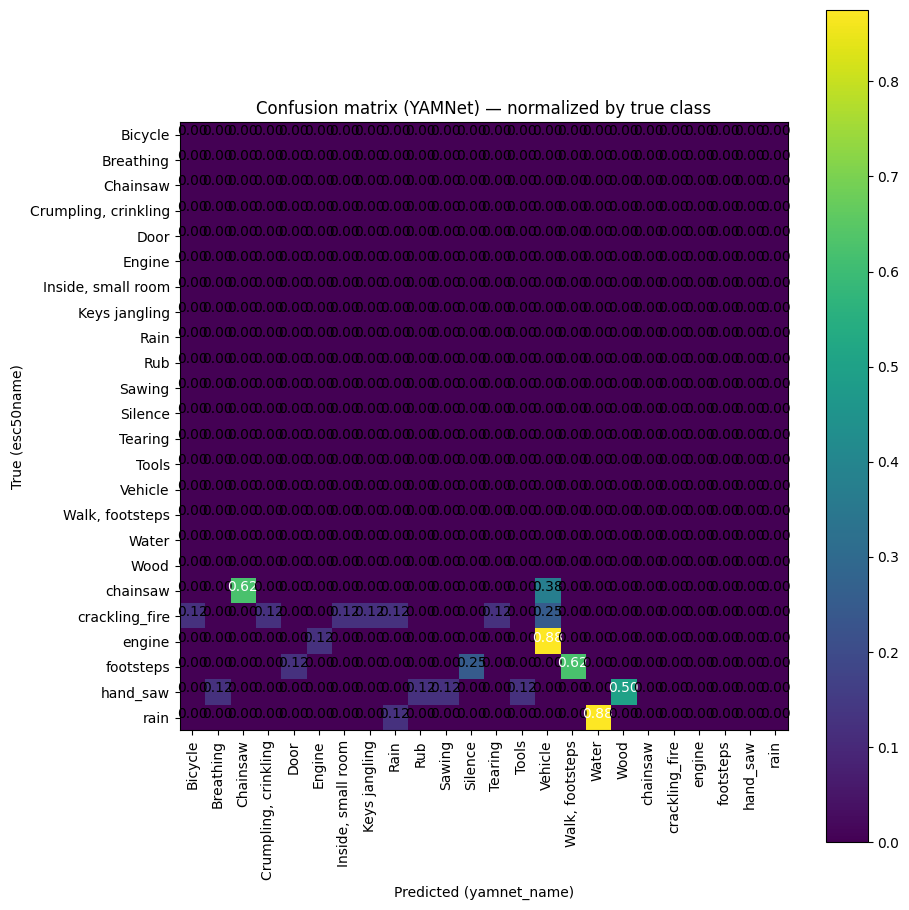

yamnet_name,Bicycle,Breathing,Chainsaw,"Crumpling, crinkling",Door,Engine,"Inside, small room",Keys jangling,Rain,Rub,Sawing,Silence,Tearing,Tools,Vehicle,"Walk, footsteps",Water,Wood
esc50name,,,,,,,,,,,,,,,,,,
chainsaw,0,0,5,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0
crackling_fire,1,0,0,1,0,0,1,1,1,0,0,0,1,0,2,0,0,0
engine,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,0,0,0
footsteps,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,5,0,0
hand_saw,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,4
rain,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,7,0


Tabela (esc50name x yamnet_name) salva em: /kaggle/working/esc50_vs_yamnet_table_fold5.csv


In [14]:
# imports necessários
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
import itertools
from sklearn import metrics
from IPython.display import display


# função para carregar e garantir 16kHz mono float32
def load_wav_16k(path, target_sr=16000):
    # tenta usar librosa (mais robusto)
    try:
        import librosa
        wav, sr = librosa.load(path, sr=target_sr, mono=True)
        return wav.astype(np.float32)
    except Exception:
        # fallback para scipy + resample_poly
        from scipy.io import wavfile
        from scipy.signal import resample_poly
        sr, data = wavfile.read(path)
        # converter para float32 em -1..1 se for int
        if data.dtype.kind == 'i':
            # int16 or int32
            maxv = float(2 ** (8 * data.dtype.itemsize - 1))
            data = data.astype(np.float32) / maxv
        elif data.dtype.kind == 'u':
            # unsigned
            data = data.astype(np.float32) / (2 ** (8 * data.dtype.itemsize))
            data = data - 0.5
        else:
            data = data.astype(np.float32)
        # se stereo -> mono
        if data.ndim > 1:
            data = np.mean(data, axis=1)
        # resample se necessário
        if sr != target_sr:
            gcd = np.gcd(sr, target_sr)
            up = target_sr // gcd
            down = sr // gcd
            data = resample_poly(data, up, down).astype(np.float32)
        return data.astype(np.float32)

# --- 1) criar dataframe de teste (fold == 5) a partir do filtered_pd que você mostrou ---
# assume filtered_pd já definido no notebook
test_df = filtered_pd[filtered_pd['fold'] == 5].reset_index(drop=True)
print(f"Test samples (fold==5): {len(test_df)}")

# --- 2) iterar pelos arquivos wav, rodar YAMNet e registrar resultados ---
results = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="YAMNet on test wavs"):
    wav_path = row['filename']
    true_name = row['category']  # seu campo com a classe verdadeira (esc50 name)
    try:
        waveform = load_wav_16k(wav_path, target_sr=16000)
    except Exception as e:
        print(f"Erro ao carregar {wav_path}: {e}")
        continue

    # chama YAMNet exatamente como seu snippet
    yamnet_out = yamnet_model(waveform)  # scores, embeddings, spectrogram
    # extrai scores e embeddings seguindo seu exemplo
    if isinstance(yamnet_out, (list, tuple)) and len(yamnet_out) >= 1:
        scores = yamnet_out[0]
        embeddings = yamnet_out[1] if len(yamnet_out) > 1 else None
    else:
        scores = yamnet_out
        embeddings = None

    # média no tempo / janelas
    if isinstance(scores, tf.Tensor):
        class_scores = tf.reduce_mean(scores, axis=0).numpy()
    else:
        class_scores = np.mean(np.asarray(scores), axis=0)

    top_class_idx = int(np.argmax(class_scores))
    yamnet_name = class_names[top_class_idx]

    results.append({
        'filename': wav_path,
        'esc50name': true_name,
        'yamnet_name': yamnet_name,
        'top_class_idx': top_class_idx
    })

# transformar em DataFrame
results_df = pd.DataFrame(results)
print("Primeiras linhas do resultado:")
display(results_df.head(10))

# salvar CSV para inspeção posterior
csv_out = "/kaggle/working/yamnet_test_preds_fold5.csv"
results_df.to_csv(csv_out, index=False)
print(f"Salvo CSV em: {csv_out}")

# --- 3) criar lista ordenada de rótulos (nomes) para a confusão ---
# usar a união de nomes verdadeiros e previstos (mantém todas as classes presentes no teste)
labels = sorted(list(set(results_df['esc50name'].unique()).union(set(results_df['yamnet_name'].unique()))))
name2idx = {name: i for i, name in enumerate(labels)}

y_true_idx = results_df['esc50name'].map(name2idx).to_numpy()
y_pred_idx = results_df['yamnet_name'].map(name2idx).to_numpy()

# --- 4) métricas e classification report ---
print("\nClassification report (macro/weighted) — por nome de classe:")
print(metrics.classification_report(y_true_idx, y_pred_idx, labels=list(range(len(labels))), target_names=labels, zero_division=0))

acc = metrics.accuracy_score(y_true_idx, y_pred_idx)
print(f"Accuracy (overall): {acc:.4f}")

# --- 5) plot matriz de confusão (normalizada por true class) ---
cm = metrics.confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(labels))))
with np.errstate(all='ignore'):
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(max(8, len(labels)*0.4), max(6, len(labels)*0.4)))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Confusion matrix (YAMNet) — normalized by true class")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=90)
plt.yticks(tick_marks, labels)

fmt = '.2f'
thresh = cm_norm.max() / 2.0 if cm_norm.size else 0.5
for i, j in itertools.product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    plt.text(j, i, format(cm_norm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm_norm[i, j] > thresh else "black")

plt.ylabel('True (esc50name)')
plt.xlabel('Predicted (yamnet_name)')
plt.tight_layout()

conf_path = "/kaggle/working/confusion_yamnet_fold5.png"
plt.savefig(conf_path, bbox_inches='tight', dpi=200)
print(f"Confusion matrix salva em: {conf_path}")
plt.show()

# --- 6) tabela solicitada: esc50name vs yamnet_name (agrupar contagens) ---
ct = results_df.groupby(['esc50name', 'yamnet_name']).size().reset_index(name='count')
# pivot para tabela
pivot_table = ct.pivot(index='esc50name', columns='yamnet_name', values='count').fillna(0).astype(int)
display(pivot_table)

# salvar pivot como CSV se quiser
pivot_csv = "/kaggle/working/esc50_vs_yamnet_table_fold5.csv"
pivot_table.to_csv(pivot_csv)
print(f"Tabela (esc50name x yamnet_name) salva em: {pivot_csv}")
